In [19]:
# Load libraries
from pandas import read_csv
from pandas.plotting import scatter_matrix
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
# Libraries used in this project:
# pandas - for data manipulation and analysis
# matplotlib - for data visualization
# scikit-learn (sklearn) - for machine learning algorithms and tools including:
#   - model_selection: train_test_split, cross_val_score, StratifiedKFold for splitting/validating data
#   - metrics: for model evaluation metrics
#   - Various ML algorithms:
#     - LogisticRegression
#     - DecisionTreeClassifier 
#     - KNeighborsClassifier
#     - LinearDiscriminantAnalysis
#     - GaussianNB (Naive Bayes)
#     - SVC (Support Vector Classification)


In [21]:
from sklearn import datasets

iris = datasets.load_iris()

In [22]:
import pandas as pd

iris_df = pd.DataFrame(data = iris.data,columns = iris.feature_names)

iris_df['species'] = iris.target
iris_df['species'] = iris_df['species'].map({0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'})  # Map target numbers to species names



In [23]:
print(iris_df.shape)

(150, 5)


In [24]:
print(iris_df.head(20))

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                 5.1               3.5                1.4               0.2   
1                 4.9               3.0                1.4               0.2   
2                 4.7               3.2                1.3               0.2   
3                 4.6               3.1                1.5               0.2   
4                 5.0               3.6                1.4               0.2   
5                 5.4               3.9                1.7               0.4   
6                 4.6               3.4                1.4               0.3   
7                 5.0               3.4                1.5               0.2   
8                 4.4               2.9                1.4               0.2   
9                 4.9               3.1                1.5               0.1   
10                5.4               3.7                1.5               0.2   
11                4.8               3.4 

In [25]:
#provides a ststitcal summary
print(iris_df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [26]:
print(iris_df.groupby('species').size())

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


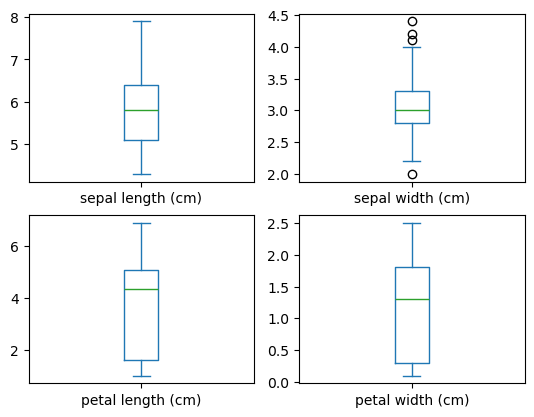

In [28]:
iris_df.plot(kind = 'box',subplots = True,layout = (2,2),sharex= False,sharey = False)
plt.show()

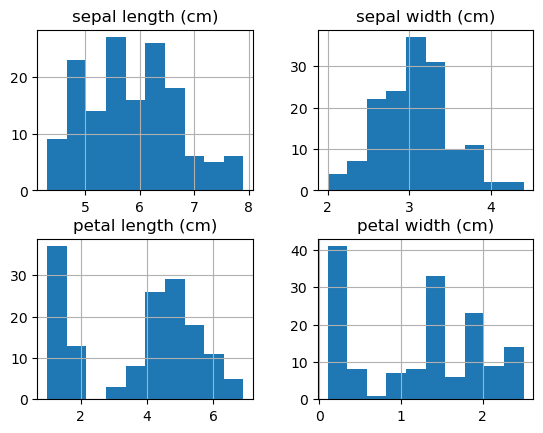

In [29]:
iris_df.hist()
plt.show()

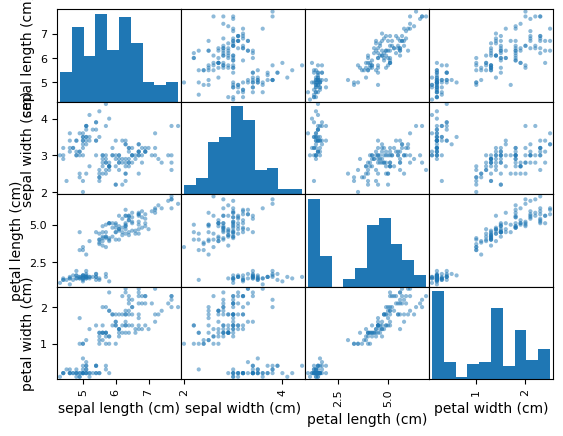

In [30]:
#scatter matrix 
scatter_matrix(iris_df)
plt.show()

In [32]:
array = iris_df.values
X = array[:,:4]
y = array[:,4]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 1)

In [34]:
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))
# evaluate each model in turn
results = []
names = []
for name, model in models:
 kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
 cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
 results.append(cv_results)
 names.append(name)
 print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

LR: 0.941667 (0.065085)
LDA: 0.975000 (0.038188)
KNN: 0.958333 (0.041667)
CART: 0.950000 (0.055277)
NB: 0.950000 (0.055277)
SVM: 0.983333 (0.033333)


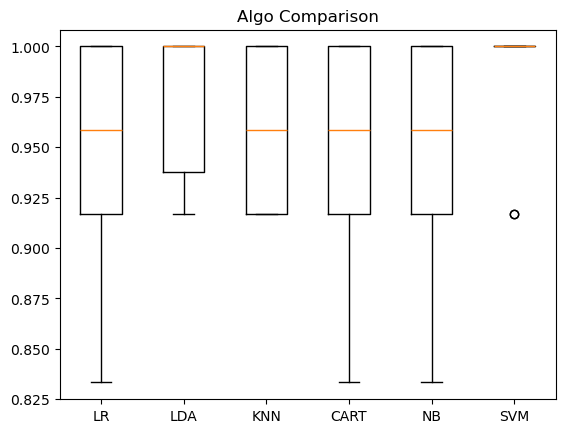

In [35]:
plt.boxplot(results,labels = names)
plt.title("Algo Comparison")
plt.show()

In [39]:
#now that SVM is shown to be accurate we will make decison based on that
model = SVC(gamma = 'auto')
model.fit(X_train,y_train)
predictions = model.predict(X_test)

In [43]:
# Evaluate predictions
print(accuracy_score(y_test, predictions))
print("-------------------------------------------------------------------")
print(confusion_matrix(y_test, predictions))
print("-------------------------------------------------------------------")
print(classification_report(y_test, predictions))


0.9666666666666667
-------------------------------------------------------------------
[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]
-------------------------------------------------------------------
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.86      1.00      0.92         6

       accuracy                           0.97        30
      macro avg       0.95      0.97      0.96        30
   weighted avg       0.97      0.97      0.97        30

